<a href="https://colab.research.google.com/github/siddhartha-sai-17/Deep-Learning/blob/main/Recurrent_Neural_Network(RNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving optimized_waste_management_data.csv to optimized_waste_management_data.csv


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('optimized_waste_management_data.csv')

In [4]:
df


,date,waste_volume,organic_waste,recyclable_waste,hazardous_waste,collection_frequency,landfill_capacity_used,recycling_rate
0,01-01-2020,48.85,31.49,12.55,4.81,Weekly,55.87,47.37
1,02-01-2020,49.45,29.76,14.76,4.94,Weekly,51.91,41.70
2,03-01-2020,51.03,32.29,13.65,5.09,Bi-weekly,53.08,58.73
3,04-01-2020,54.70,35.09,14.36,5.25,Bi-weekly,52.04,39.34
4,05-01-2020,51.74,29.99,16.87,4.88,Bi-weekly,48.01,40.45
...,...,...,...,...,...,...,...,...
1456,27-12-2023,55.85,31.57,18.99,5.30,Bi-weekly,52.63,42.39
1457,28-12-2023,52.84,30.63,17.99,4.22,Bi-weekly,57.08,42.82
1458,29-12-2023,59.21,33.53,20.53,5.16,Bi-weekly,49.94,43.88
1459,30-12-2023,53.66,31.85,16.64,5.18,Bi-weekly,47.90,46.69


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    1461 non-null   object 
 1   waste_volume            1461 non-null   float64
 2   organic_waste           1461 non-null   float64
 3   recyclable_waste        1461 non-null   float64
 4   hazardous_waste         1461 non-null   float64
 5   collection_frequency    1461 non-null   object 
 6   landfill_capacity_used  1461 non-null   float64
 7   recycling_rate          1461 non-null   float64
dtypes: float64(6), object(2)
memory usage: 91.4+ KB


In [7]:
df.describe()

,waste_volume,organic_waste,recyclable_waste,hazardous_waste,landfill_capacity_used,recycling_rate
count,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000
mean,50.158919,30.135010,15.062491,4.961355,54.862266,44.393060
std,8.771361,7.635123,4.029920,1.019074,5.024692,5.267204
min,28.810000,10.480000,4.230000,1.990000,38.310000,29.140000
25%,43.660000,23.740000,11.730000,4.270000,51.570000,40.790000
50%,50.980000,30.040000,15.020000,4.970000,54.810000,44.310000
75%,56.590000,36.650000,18.330000,5.620000,58.190000,48.140000
max,70.830000,48.540000,25.160000,8.240000,71.030000,59.960000


In [8]:
df.shape

(1461, 8)

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Dense

# **Handling Missing Data**

Missing values can affect the training . We fill them using forward fill

In [12]:
df = df.fillna(method='ffill')

/tmp/ipykernel_221/569672361.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [15]:
# Extract Feature to predict
# We only use the waste column for forecasting
waste_data = df[['waste_volume']]

# **Normalize the Data**
Neural networks work better when data are scaled between 0 and 1

In [16]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(waste_data)

# **Convert Data into Sequence**

RNN requries sequential input

Example:

Previous 10 days -> Predict next day

In [18]:
def create_seq(data,seq_length):
  X=[]
  y=[]
  for i in range(len(data)-seq_length):
    X.append(data[i:i+seq_length])
    y.append(data[i+seq_length])
  return np.array(X),np.array(y)

# **Create Time Sequences**

In [19]:
sequence_length = 10
X,y = create_seq(scaled_data,sequence_length)
print(X.shape)
print(y.shape)

(1451, 10, 1)
(1451, 1)


# **Build the RNN Model**

Architecture

Input -> RNN Layer -> Dense Output

In [21]:
model = Sequential()
model.add(SimpleRNN(units=50,activation='tanh',input_shape=(sequence_length,1)))
# SimpleRNN(50)
# 50 neurons
# Tanh activation
# Input shape = (10 time steps , 1 feature)
model.add(Dense(1)) # One value -> next day waste

# **Compile the Model**

In [22]:
model.compile(optimizer = 'adam' , loss = 'mean_squared_error')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

# **Split Data into Training and Testing Sets**




In [23]:
split = int(0.8*len(X))
X_train = X[:split]
y_train = y[:split]
X_test = X[split:]
y_test = y[split:]

# **Train the Model**

We train the model for 50 epochs

In [24]:
history = model.fit(
    X_train,
    y_train,
    epochs = 50,
    batch_size = 16,
    validation_split = 0.1
)

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0230 - val_loss: 0.0127
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0102 - val_loss: 0.0131
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0099 - val_loss: 0.0124
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0096 - val_loss: 0.0112
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0094 - val_loss: 0.0207
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0102 - val_loss: 0.0115
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0097 - val_loss: 0.0114
Epoch 8/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0093 - val_loss: 0.0131
Epoch 9/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0093 - val_loss: 0.0125
Epoch 10/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0098 - val_loss: 0.0148
Epoch 11/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0097 - val_loss: 0.0130
Epoch 12/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0097 - val_lo

In [25]:
loss = model.evaluate(X_test,y_test)
print("Test loss:",loss)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0093 
Test loss: 0.009294397197663784


# **Make Predictions**

In [27]:
predictions = model.predict(X_test)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


# **Convert Predictions back to Original scale**

In [28]:
predictions=scaler.inverse_transform(predictions) #We trained in normalized space.
y_test_actual=scaler.inverse_transform(y_test) #Now convert back to real waste values.


# **Plot predictions vs Actual Values**

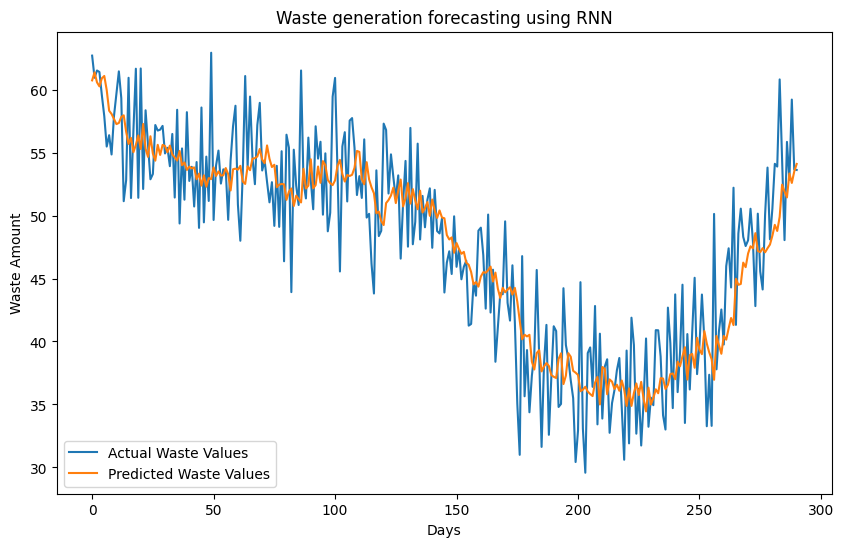

In [29]:
plt.figure(figsize=(10,6))
plt.plot(y_test_actual,label="Actual Waste Values")
plt.plot(predictions,label="Predicted Waste Values")
plt.title("Waste generation forecasting using RNN")
plt.xlabel("Days")
plt.ylabel("Waste Amount")
plt.legend()
plt.show()